# A hypergraph exploration

CC-BY Amaury Minino and James B. Wilson

This notebook explores a hypergraph using Dleto.

First need to load Julia

In [ ]:
## Uncomment if you do not have iJulia installed
# using Pkg
# Pkg.add("IJulia")
# This installs Julia's Jupyter kernel without Python dependencies
# println("IJulia installed! Restart VS Code and select Julia kernel.")

# Ensure Julia kernel is properly recognized  
# This notebook requires Julia kernel for execution and export
using IJulia
println("Julia kernel is active!")
println("Julia version: ", VERSION) # Fix Jupyter/Julia setup - Install IJulia for Julia notebooks


Next we load Dleto.

In [ ]:
include("../Dleto.jl") 

Now let us load a hypergraph tensor.


In [ ]:
hypgraph_ten = loadTensorFromFile("Hypergraph-Tensor.txt")

We can better visualize this using 3D plotting software.


In [ ]:
plotTensor(hypgraph_ten)

In [ ]:
strata = toSurfaceTensor(hypgraph_ten)
plotTensor(strata.tensor)

In [ ]:
curve = toCurveTensor(hypgraph_ten)
plotTensor(curve.tensor)

## Making a hypergraph

A hyper graph is a set of subsets.  We can provide that as a matrix of 0,1 values where the columns are the enumeration of the domain and each row is the incidence relation of being in the subset.  For example 
$$\begin{bmatrix} 1 & 0 & 1 & 1\\ 0 & 1 & 1 & 1 \end{bmatrix}$$
is a hypergraph on \(1,2,3,4\) with hyperedges $\{1,3,4\}$ and $\{2,3,4\}$.

Let us create this in code.  

In [ ]:
hypgraph_small = [ 1 0 1 1; 
                   0 1 1 1 ]
small_ten = createTensorFromIncidence3(hypgraph_small)

In [ ]:
plotTensor(small_ten)

Now for something bigger.

In [ ]:
using Random
using SparseArrays

v = 75; e=50;
# Create a random 0-1 matrix with 30 columns, 20 rows, and exactly 3 nonzeros per row
m = zeros(Int, e,v)
for i in 1:e
    cols = randperm(v)[1:3]  # Randomly select 3 columns
    m[i, cols] .= 1
end
println("Random hyper graph on ", v, " vertices, ", e, " edges")
m

In [ ]:
asTen = createTensorFromIncidence3(m)
plotTensor(asTen)

In [ ]:
strat = toSurfaceTensor(asTen)
plotTensor(strat.tensor, 0.05)

In [ ]:
plotTensor(strat.tensor, 0.1)

In [ ]:
curve = toCurveTensor(asTen)
plotTensor(curve.tensor)

In [ ]:
face = toFaceCurveTensor(asTen)
plotTensor(face.tensor)

Now for real world data from
    Simplicial closure and higher-order link prediction.
    Austin R. Benson, Rediet Abebe, Michael T. Schaub, Ali Jadbabaie, and Jon Kleinberg.
    Proceedings of the National Academy of Sciences (PNAS), 2018. 

In [1]:
# import Pkg; Pkg.add("MatrixMarket")
using IJulia
# println("Julia kernel is active!")
# println("Julia version: ", VERSION)
include("../Dleto.jl") 
using MatrixMarket
fdaData = MatrixMarket.mmread("Priamry_School_Incidence.mtx")
size(fdaData,2)
fdaTen = createTensorFromIncidence3(fdaData)
# plotTensor(fdaTen)
# strata = toSurfaceTensor(fdaTen)
# plotTensor(strata.tensor)
# curve = toCurveTensor(hypgraph_ten)
# plotTensor(curve.tensor)
# face = toFaceCurveTensor(asTen)
# plotTensor(face.tensor)

Dleto.jl loaded successfully.


29×29×29 Array{Float16, 3}:
[:, :, 1] =
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  1.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱                 ⋮              
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0

Plotting 234 points with value-proportional sizes...


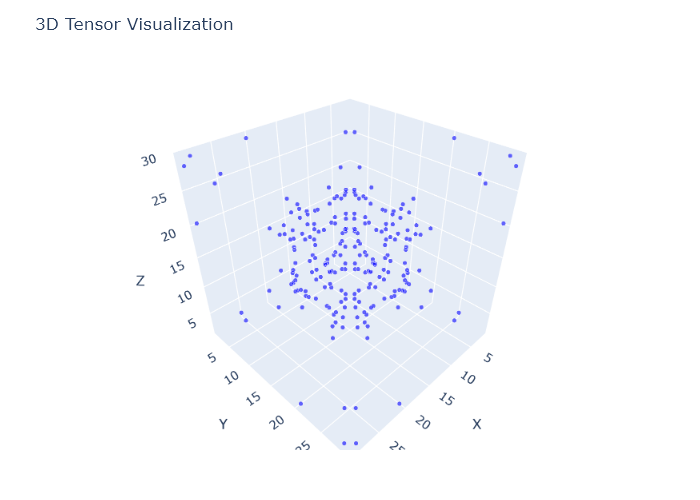

In [2]:
plotTensor(fdaTen)



	Building linear system...
	Number of blocks: (1, 3)
	Number of variables: 1305
	Sizes: (1305, 24389)
Number of coordinates: 24389
loops to do: 73167
  0.313316 seconds (617.42 k allocations: 275.297 MiB, 15.53% gc time, 69.52% compilation time)

	Computing singular vectors for (1305, 24389)...
	
eigens[1] = [-1.9812667947793746e-14, -7.054514293816785e-16, 2.4921066503283026e-16, 1.5793005725903774e-15, 1.84106041921356e-15, 3.2783930896636213e-15, 0.1374927779656748, 0.13749277796567627, 0.2565828825850223, 0.4508673686251011, 0.5743340724676717, 0.6077016395333675, 0.7281625669199179, 0.8414141150235243, 0.9550813894591583, 0.9550813894591591, 1.2322787631921666, 1.2518770690843115, 1.2518770690843144, 1.29584403769534]
  0.706391 seconds (665.13 k allocations: 46.578 MiB, 51.27% compilation time)

	Extracting matrices...
  0.023443 seconds (17.54 k allocations: 876.817 KiB, 99.86% compilation time)
  0.000005 seconds (4 allocations: 6.741 KiB)
  0.000002 seconds (5 allocations: 6.

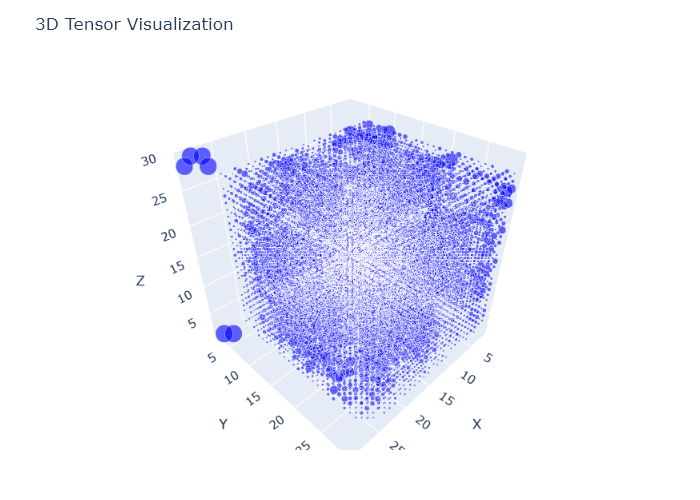

In [3]:
strata = toSurfaceTensor(fdaTen)
plotTensor(strata.tensor)


	Number of blocks: (3, 3)
	Number of variables: 1305
	Sizes: (1305, 73167)
Number of coordinates: 24389
loops to do: 219501
eigens[1] = [-1.8252014307828524e-14, 4.019975279797328e-15, 0.2749855559313683, 1.9101627789183246, 2.2193334559095317, 2.21933345590954, 2.5037541381686363, 2.596136777545021, 2.596136777545051, 2.645304802469296, 2.6514055593580563, 2.6514055593580848, 2.999999999999998, 3.00000000000001, 3.000000000000015, 3.0000000000000315, 3.3512129550672225, 3.765683224919156, 3.7656832249191994, 3.8583145104002066]
Plotting 15232 points with value-proportional sizes...


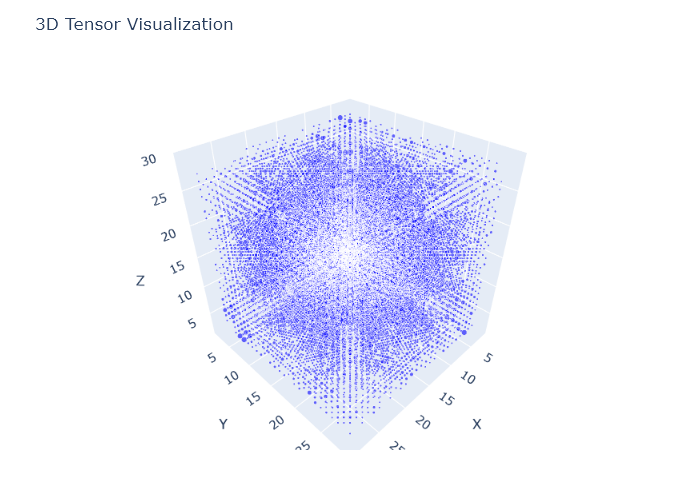

In [4]:
curve = toCurveTensor(fdaTen)
plotTensor(curve.tensor)


	Number of blocks: (1, 2)
	Number of variables: 870
	Sizes: (870, 24389)
Number of coordinates: 24389
loops to do: 48778
eigens[1] = [-1.3107141052151614e-14, 2.121949252514651e-15, 0.1374927779656746, 0.95508138945915, 0.9999999999999911, 0.9999999999999931, 1.073755723615922, 1.1583228180811809, 1.2125504828855438, 1.251877069084318, 1.3226524012346477, 1.5885987914701727, 1.6756064775336093, 1.929157255200044, 1.9357126994336649, 1.9428623700024927, 1.9761933622906211, 1.9999999999999982, 1.9999999999999993, 2.000000000000013]
Plotting 8362 points with value-proportional sizes...


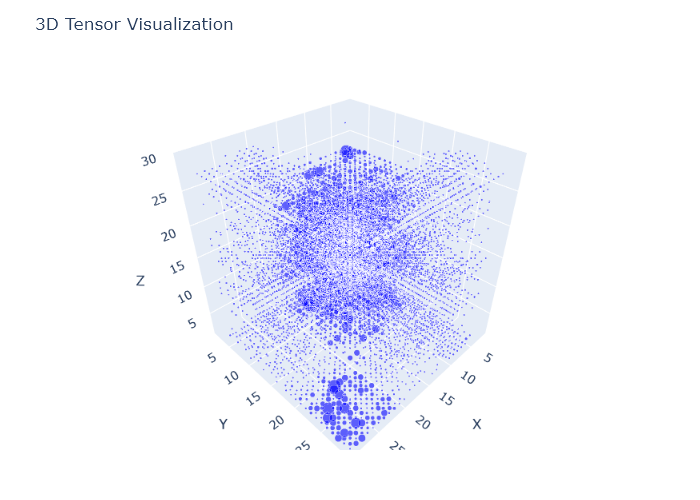

In [5]:
face = toFaceCurveTensor(fdaTen)
plotTensor(face.tensor)